In [6]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()



import os

In [7]:
# def create_subfolders(parent_directory, subfolder_names, nested_subfolder_names):
#     for folder_name in subfolder_names:
#         # Construct the full path for the new subfolder
#         subfolder_path = os.path.join(parent_directory, folder_name)
#         try:
#             # Create the main subfolder
#             os.makedirs(subfolder_path)
#             print(f"Created subfolder: {subfolder_path}")

#             # Create nested subfolders
#             for nested_folder_name in nested_subfolder_names:
#                 nested_subfolder_path = os.path.join(subfolder_path, nested_folder_name)
#                 os.makedirs(nested_subfolder_path)
#                 print(f"Created nested subfolder: {nested_subfolder_path}")
#         except OSError as error:
#             print(f"Error creating subfolder {subfolder_path}: {error}")

# # Define the parent directory
# parent_directory = "solns_runs/Ex3"
Tmax= 5
# # Generate main subfolder names T1, T2, ..., T50
# subfolder_names = [f"T{i}" for i in range(1, Tmax)]

# # Generate nested subfolder names N100, N200, ..., N1500
# nested_subfolder_names = [f"N{i}" for i in range(100, 1501, 100)]

# # Create the subfolders
# create_subfolders(parent_directory, subfolder_names, nested_subfolder_names)


In [8]:
def g(x):
    return np.array([x[0]**2 + x[1]**2 - 1])

def grad_g(x):
    return np.array([2*x[0], 2*x[1]])

def F(x, l):
    x1, x2 = x
    return np.array([(2*x1 - x2 - 1)+l*grad_g(x)[0], (2*x2 - 0.5*x1 - 2)+l*grad_g(x)[1]])



def proj_X_opt(x):
    """
    Project point x = (x1, x2) onto
    X = { (u,v) | u >= 0, v >= 0, u+v <= 1 }
    """
    x = np.asarray(x)

    # Objective: minimize squared distance
    def objective(u):
        return 0.5 *np.sum((u - x)**2)

    # Constraints
    constraints = [
        
        {"type": "ineq", "fun": lambda u: 1 - u[0]**2 - u[1]**2} # u+v <= 1
    ]

    # Initial guess
    z0 = np.maximum(x, 0)  # clip negative values to start inside nonnegative orthant
    bounds = [(0, 1), (0, 1)]
#     z0= np.random.uniform(0, 1, size=2)

    result = minimize(objective, z0, constraints= constraints, bounds= bounds)

    return result.x
def const(x):
    return 1-(x[0]**2+x[1]**2)

# def vi_solver(l, step=0.01, max_iter=1000, tol=1e-6):
#     x0= np.random.uniform(0, 1, size=2)
#     x = x0.copy()
   
#     for _ in range(max_iter):
       
#         x_new = proj_X_opt(x - step * F(x, l))
#         if np.linalg.norm(x_new - x) < tol:
#             if np.linalg.norm(const(x_new)*l)<= 1e-6:
#                 return x_new
#             else:
#                 return None
#         else:
#             x = x_new
        
        
        
        
#     print(const(x), l)
#     print("BEN")
#     if np.linalg.norm(const(x)*l)== 0.0:
#         return x
#     else:
#         return None

In [30]:
def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0]**2 + x[1]**2)])

def project_into_feasible_set(x,constraint_function):
    result = minimize(lambda x_prime: np.linalg.norm(x_prime - x), x, constraints={'type': 'ineq', 'fun': constraint_function},bounds= [(0,1),(0,1)])
    return result.x

num_iterations= 100
def projected_gradient_descent_kkt(F,initial_x, initial_y, lambda_value,lamd):
    x = initial_x.copy()
    y = initial_y.copy()

    grad_obj = F(y,lamd)
    x = project_into_feasible_set(x - lambda_value * grad_obj, constraint_function)
    return x

def vi_solver(lamd):
    n= 2
    x0= np.random.uniform(0, 1, size=n)
    y0= x0.copy()

    T= 1000
    x,y= np.zeros((T+1,n)),np.zeros((T+1,n))
    x[0]= x0
    y[0]= y0
    lambda_value_0= np.random.uniform(0, alpha)
#     print(x0)
    x[1]= projected_gradient_descent_kkt(F,x[0], y[0], lambda_value_0, lamd)
    y[1]= 2*x[1]-x[0]
    for i in range(1,T):

        if np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))!= 0.0:
            lambda_value= np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd)))
        else:
            lambda_value= 1e-8 # np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))+1e-8)
      # break
#         print(x[i])
        x[i+1]= projected_gradient_descent_kkt(F,x[i], y[i], lambda_value,lamd)
        y[i+1]= 2*x[i+1]-x[i]
#         print(x[i+1])
        
#         print(np.linalg.norm(x[i+1] - x[i]))
        
        if (np.linalg.norm(x[i+1] - x[i])) <= 1e-4:
            if np.abs(const(x[i+1]) * lamd) <= 1e-4:
                return x[i+1]

#     return x[T]

In [31]:
# F(np.random.uniform(0, 1, size=2), 0.1)
vi_solver(lamd= 0.0)

array([0.58030731, 0.81439761])

In [32]:
# vi_solver(l= 0.05, step=0.01, max_iter=1000, tol=1e-6)

In [33]:
def organize_solutions(solns):
    set_of_points= []
    for sol in solns:
        if sol is not None:
            set_of_points.append(list(sol))

    return set_of_points

def discretize_time_interval(T,num_points):
    """
    Discretize the time interval [0, T] with a given time step (delta_t).

    Parameters:
    - T: Total time duration
    - delta_t: Time step size.

    Returns:
    - time_points: List of discretized time points
    """
    start = 0#T-1

    # Calculate the width of each sub-interval
    interval_width = (T - start) / (num_points - 1)

    # Generate the points
    points = [start + i * interval_width for i in range(num_points)]

    return points

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
#number_points_list= [10, 20]
#n_runs= [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60]
#number_points_list= [100, 200]
T_list= [T for T in range(1,Tmax)]
n_runs= [10]

def run_for_lam(lmb):
    results = Parallel(n_jobs=4)(delayed(vi_solver)(lam) for lam in lmb)
#     results= []
#     for l in lmb:
#         results.append(vi_solver(l))
    set_of_points= organize_solutions(results)
    return set_of_points

def run_n(lmb, n_r= 10):
    results = Parallel(n_jobs=8)(delayed(run_for_lam)(lmb) for _ in range(n_r))
    set_of_points= organize_solutions(results)
    res= []
    for i in set_of_points:
        res.extend(i)
    return np.array(res)
def run_(lambd):
    results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
    set_of_points= organize_solutions(results)
    return set_of_points
def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=-1)(delayed(run_)(lmb) for _ in range(n_runs))
#     results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points
def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=-1)(delayed(run_)(lmb) for _ in range(n_runs))
#     results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points


# def run_for_different_runs(T,n_r= 10):
#     lambd = Parallel(n_jobs=-1)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
#     result= run_for_lam_run(lambd,n_r)
   
#     for idx_run in range(n_r):
#         results= result[idx_run]
# # #         results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
#         for n_points in range(len(results)):
#             np.savetxt('./solns_runs/Ex3/T'+str(T)+'/'+'N'+str(number_points_list[n_points])+"/"+str(idx_run+1)+"_"+"solns"+'_'+'run'+str(n_r)+'_'+str(number_points_list[n_points])+'pts'+'.txt', np.array(results[n_points]), delimiter=',')


# def run_for_T(T):    
#     #for n_r in n_runs:
#     run_for_different_runs(T,n_r= 10)
    
# Parallel(n_jobs=-1)(delayed(run_for_different_runs)(T) for T in T_list)





In [34]:
T= 2
n_runs= 1
lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)

In [35]:
# vi_solver(l= 0.05, step=0.01, max_iter=1000, tol=1e-6)
# vi_solver(0.0)

In [36]:
# len(lambd[0])

In [37]:
tt= run_for_lam(lambd[0])

In [38]:
tt

[[0.6332697147287095, 0.7739311780841686],
 [0.6775073168980675, 0.7355160365832043],
 [0.6199701635327391, 0.7846253922862678],
 [0.6324271867140047, 0.7746199567727474],
 [0.6559422160520497, 0.7548111103494548],
 [0.6089505411442604, 0.7932081964499834],
 [0.5954030183945143, 0.8034272188601604],
 [0.6444825779931811, 0.7646190613282363],
 [0.6336611691162134, 0.773610761129407],
 [0.4789416016504233, 0.8778467654030383],
 [0.6833690460892415, 0.730069927329081],
 [0.6008967920346712, 0.799326629682327],
 [0.6471977821044159, 0.7623222266894442],
 [0.6541618476092177, 0.7563546190549537],
 [0.6287006939533991, 0.7776473734551062],
 [0.6074143725303075, 0.794385198085142],
 [0.6110302689467496, 0.79160725912016],
 [0.6186831149654217, 0.7856406551057857],
 [0.5927501276183719, 0.8053864222851186],
 [0.6116488630674176, 0.7911293824484913],
 [0.6203930072328423, 0.7842912766596105],
 [0.6177014411473645, 0.7864129716682631],
 [0.5992879773516004, 0.8004829321370649]]

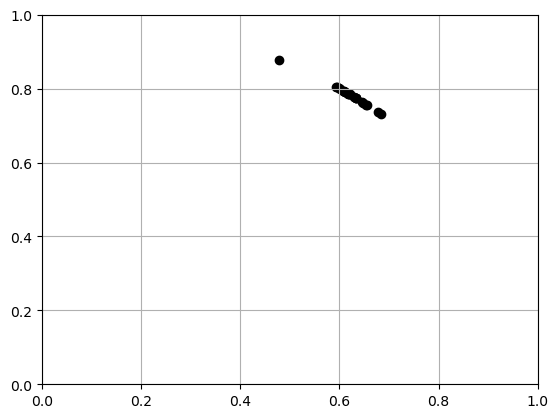

In [39]:
plt.scatter(np.array(tt)[:,0], np.array(tt)[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid(True)
plt.show()

In [40]:
# data= []
# len(lambd[0])

In [41]:
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [42]:
# i= 14
# plt.scatter(np.array(data[i])[:,0], np.array(data[i])[:,1], c= 'black')
# plt.xlim([0,1])
# plt.ylim([0,1])
# plt.grid(True)
# plt.show()

In [43]:
# data[0]

In [44]:
# T= 5 
# n_runs= 5 for each num points
#

In [45]:
# all_data= dict.fromkeys(range(len(data)), 0)

In [46]:
# for i in range(len(data)):
#     all_data[i]= data[i]

In [47]:
# import json
# with open("Ex3PVI.json", "w") as f:
#     json.dump(all_data, f)

In [48]:
## all T

In [49]:
def runT(T):
    data= []
    lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
    for l in range(len(lambd)):
        res= run_n(lambd[l])
        data.append(res)
    return data
    

In [50]:
T_list= [1, 2, 3, 4, 5]

T_data= dict.fromkeys(range(1, len(T_list)+1), 0)

T_data

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

In [51]:
for T in T_list:
    print("Running for T= ", T)
    res= runT(T)
    T_data[T]= res

Running for T=  1
Running for T=  2
Running for T=  3
Running for T=  4
Running for T=  5


In [53]:

import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex3PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

# Track $T_{max}$

In [34]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()



import os
import json


In [35]:
def constraint_function(x):
    return 1-(x[0]**2+x[1]**2)

In [36]:
number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]

In [37]:
with open('./Ex3PVIT.json') as f:
    dataT= json.load(f)

In [38]:
T_list= [1, 2, 3, 4, 5, 6, 7, 8] # T= 1 is the one giving meaningfull solution[1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)




for T in T_list:
    data_all= []

    for i in range(len(number_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[str(T)][i])):
                # print(data[str(i)][t])
                if np.abs(constraint_function(dataT[str(T)][i][t]))<= 1e-8:
                    res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all
    
    
res_all= []

for i in range(len(number_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)
    
data_all= res_all

In [39]:
dt_res= []

for i in range(len(number_points_list)):
    cleaned_data = [x for x in data_all[i] if x != []]
    # print(cleaned_data)
    dt_res.append(cleaned_data)
    # break

data_all= dt_res

In [29]:
#data_dict[1][14]

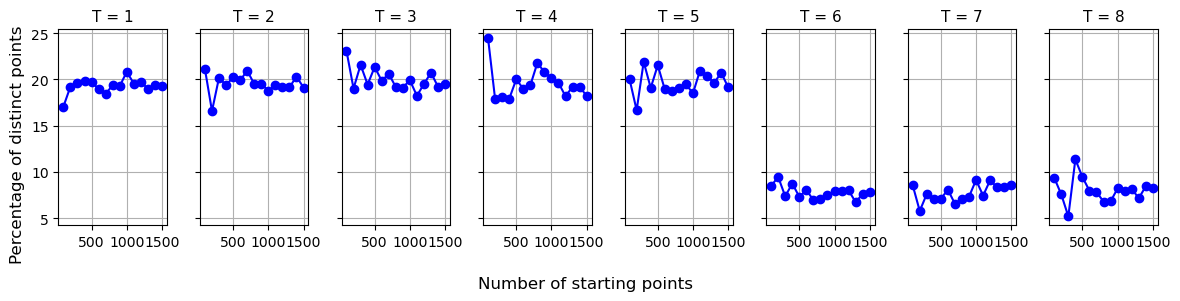

In [40]:
import numpy as np

def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points



res_T= {
    1: None, 2: None, 3: None, 4: None, 5:None, 6:None, 7:None, 8:None
}
Tmax= 8

dist_= None
for t in range(1, Tmax+1):
    dist_= []

    for (idx, pt) in enumerate(number_points_list):




        num, distinct_points = count_repeated_points(np.array(data_dict[t][idx]))
        distinct_points= np.array(distinct_points)
        dist_.append((len(distinct_points)/(len(np.array(data_dict[t][idx]))))*100)
    res_T[t]= dist_

    
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(100, 1501, 100)

fig, axes = plt.subplots(1, Tmax, figsize=(12,3), sharex=True, sharey=True)

for T in range(1, Tmax+1):
    ax = axes[T-1]
    ax.plot(x, res_T[T], marker='o', c= 'blue')
    ax.set_title(f"T = {T}", fontsize=11)
    ax.grid(True)

# global labels
fig.supxlabel("Number of starting points", fontsize=12)
fig.supylabel("Percentage of distinct points", fontsize=12)

plt.tight_layout()
#plt.savefig("Ex3Tmax.png", dpi=300, bbox_inches="tight")
plt.show()

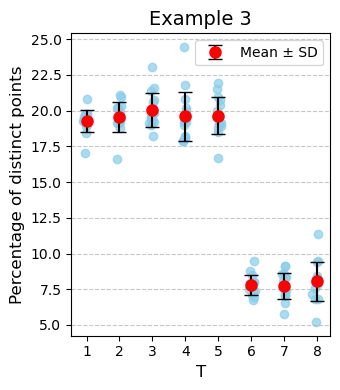

In [41]:
# Compute mean and std for each key
keys = list(res_T.keys())
means = [np.mean(res_T[k]) for k in keys]
stds = [np.std(res_T[k]) for k in keys]

plt.figure(figsize=(3.5,4))

# Plot all points with some horizontal jitter
for i, k in enumerate(keys):
    y = res_T[k]
    x = np.random.normal(loc=i+1, scale=0.05, size=len(y))  # jitter for visibility
    plt.scatter(x, y, color='skyblue', alpha=0.7, label='_nolegend_')

# Overlay mean as a red marker with error bars
plt.errorbar(keys, means, yerr=stds, fmt='o', color='red', ecolor='black', elinewidth=1.5,
             capsize=5, markersize=8, label='Mean ± SD')

# Formatting
plt.xticks(keys)
plt.xlabel('T', fontsize=12)
plt.ylabel('Percentage of distinct points', fontsize=12) # mean PDP across the number of starting points.
plt.title('Example 3', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("Ex3Tmax.png", dpi=300, bbox_inches="tight")
plt.show()